<a href="https://colab.research.google.com/github/peculab/DFTDescriptorPipeline/blob/main/azoarene_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!rm -rf /usr/local/lib/python3.11/dist-packages/descriptors

In [18]:
# ✅ Reset environment
%cd /content
import shutil, os, sys, importlib

# 🔁 Uninstall pip-installed descriptors
!pip uninstall -y descriptors

# 🔥 Clear cached modules
for k in list(sys.modules.keys()):
    if k.startswith("descriptors"):
        del sys.modules[k]

# 🧹 Remove previous repo
if os.path.exists("DFTDescriptorPipeline"):
    shutil.rmtree("DFTDescriptorPipeline")

/content


In [19]:
# ✅ Install required packages
!pip install morfeus-ml scikit-learn joblib matplotlib openpyxl

# ✅ Clone the latest repo
!git clone https://github.com/peculab/DFTDescriptorPipeline.git

Cloning into 'DFTDescriptorPipeline'...
remote: Enumerating objects: 762, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (166/166), done.
remote: Total 762 (delta 107), reused 15 (delta 8), pack-reused 567 (from 1)
Receiving objects: 100% (762/762), 36.22 MiB | 20.41 MiB/s, done.
Resolving deltas: 100% (453/453), done.


In [20]:
# ✅ Set module path
from morfeus import read_xyz, Sterimol
from morfeus.utils import get_radii

import shutil, os, sys, importlib
sys.path.insert(0, "/content/DFTDescriptorPipeline/descriptors")
import extractor_regr
import glob, os
importlib.reload(extractor_regr)

<module 'extractor_regr' from '/content/DFTDescriptorPipeline/descriptors/extractor_regr.py'>

Streaming output truncated to the last 5000 lines.
❌ ['Ar1_Ar_e', 'Ar1_Ar_Ster_B5', 'Ar2_Ar_LUMO', 'Ar2_L_C1_C2', 'Ar2_Ar_e'] | skipped
❌ ['Ar1_Ar_e', 'Ar1_Ar_Ster_B5', 'Ar2_Ar_LUMO', 'Ar2_Ar_c', 'Ar2_Ar_Ster_L'] | skipped
❌ ['Ar1_Ar_e', 'Ar1_Ar_Ster_B5', 'Ar2_L_C1_C2', 'Ar2_Ar_c', 'Ar2_Ar_Ster_B5'] | skipped
❌ ['Ar1_Ar_e', 'Ar1_Ar_Ster_B5', 'Ar2_Ar_b', 'Ar2_Ar_f', 'Ar2_Ar_Ster_B5'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_C2', 'Ar2_Ar_v_C=O', 'Ar2_Ar_a'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_C2', 'Ar2_Ar_v_C=O', 'Ar2_Ar_Ster_B1'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_HOMO', 'Ar2_Ar_g'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_c', 'Ar2_Ar_g'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_=O', 'Ar2_Ar_b', 'Ar2_Ar_Ster_L'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_-O', 'Ar2_Ar_dp', 'Ar2_Ar_Ster_B5'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_Ar_b', 'Ar2_Ar_NBO_-O', 'Ar2_Ar_HOMO', 'Ar2_Ar_Ster_L'] | skipped
❌ ['Ar1_Ar_a', 'Ar1_A

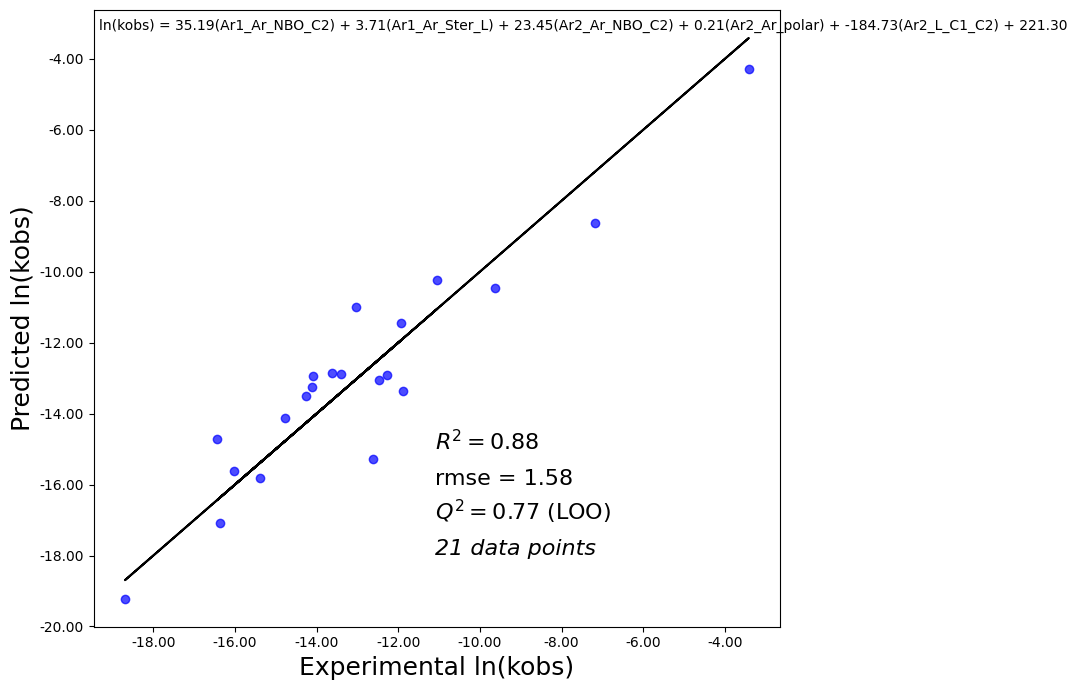


✅ Analysis complete!


In [21]:
# 指向原始資料（包含 Ar1、Ar2、...）
data_dir = "/content/DFTDescriptorPipeline/examples/azoarene"
xlsx_path = glob.glob(os.path.join(data_dir, "*.xlsx"))[0]
log_folder = os.path.join(data_dir, "logfiles")

# 一鍵執行
df, results, best_model = extractor_regr.run_full_pipeline(
    log_folder=log_folder,
    xlsx_path=xlsx_path,          # 直接用原檔
    target='ln(kobs)'
)